In [1]:
print("بسم الله الرحمن الرحيم")

بسم الله الرحمن الرحيم


# Project Title : Statistical Exploratory Data Analysis and Data Visualization of Global Travel Destinations 

# Summary

This project performs a comprehensive statistical exploratory data analysis (EDA) on global travel destinations to uncover meaningful insights about cost, ratings, visitor trends, seasonality, and UNESCO status, helping Tourists and Businesses to make data-driven decisions and optimize travel experiences.
The dataset is visualized through univariate, bivariate, and multivariate plots, along with correlation graph and analysis. 

**The Data Visualization and Analysis provides actionable insights for:**
* Global Tourists
* Traveling agencies,
* Government tourism Departments
* Hotel Businesses and managements
* Airline and Transportation Companies
  
  



**Tools Used**

* Kaggle
* CSV

**Languages and Libraries**
* Python
* NumPy
* Pandas
* Matplotlib
* Seaborn

**Statistical Methods**
* Quick Summary 
* Mean
* Median
* Mode

# Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from statistics import multimode

# Data upload to drive


In [3]:
df = pd.read_csv("/kaggle/input/destination-data/Data.csv")

This dataset represents various popular global tourist destinations around the world. Each row includes attributes related to the destination's Country & Continents, destination type, traveling cost, Average ratings, seasonal suitability, Popularity, Annual Visitors numbers,and cultural or historical significance.

# Read CSV

In [4]:
df

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Destination Name,Country,Continent,Type,Avg Cost (USD/day),Best Season,Avg Rating,Annual Visitors (M),UNESCO Site,Zip,unnamed1
0,Serene Temple,Morocco,Africa,Beach,174.84,Summer,4.5,7.45,No,NaN,NaN
1,Sacred Valley,Germany,Europe,Religious,94.41,Summer,4.6,1.98,No,NaN,NaN
2,Serene Temple,South Africa,Africa,Adventure,228.96,Summer,4.7,0.70,Yes,NaN,NaN
3,Sacred Plaza,Australia,Oceania,Nature,120.96,Summer,4.3,2.24,No,NaN,NaN
4,Golden Ruins,Mexico,North America,Adventure,162.10,Spring,3.9,4.60,No,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.columns

Index(['Destination Name', 'Country', 'Continent', 'Type',
       'Avg Cost (USD/day)', 'Best Season', 'Avg Rating',
       'Annual Visitors (M)', 'UNESCO Site', 'Zip', 'unnamed1'],
      dtype='object')

In [6]:
df.shape

(2006, 11)

# Data Cleaning

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2006 entries, 0 to 2005
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Destination Name     2000 non-null   object 
 1   Country              1993 non-null   object 
 2   Continent            2000 non-null   object 
 3   Type                 2001 non-null   object 
 4   Avg Cost (USD/day)   2000 non-null   float64
 5   Best Season          2000 non-null   object 
 6   Avg Rating           2000 non-null   float64
 7   Annual Visitors (M)  2000 non-null   float64
 8   UNESCO Site          2000 non-null   object 
 9   Zip                  0 non-null      float64
 10  unnamed1             0 non-null      float64
dtypes: float64(5), object(6)
memory usage: 172.5+ KB


# Drop Unimportant Columns

In [8]:
df.drop (['Zip','unnamed1'], axis = 1, inplace = True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2006 entries, 0 to 2005
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Destination Name     2000 non-null   object 
 1   Country              1993 non-null   object 
 2   Continent            2000 non-null   object 
 3   Type                 2001 non-null   object 
 4   Avg Cost (USD/day)   2000 non-null   float64
 5   Best Season          2000 non-null   object 
 6   Avg Rating           2000 non-null   float64
 7   Annual Visitors (M)  2000 non-null   float64
 8   UNESCO Site          2000 non-null   object 
dtypes: float64(3), object(6)
memory usage: 141.2+ KB


# Drop or Impute Null Values 

In [10]:
# check for null values
pd.isnull(df)

,Destination Name,Country,Continent,Type,Avg Cost (USD/day),Best Season,Avg Rating,Annual Visitors (M),UNESCO Site
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
2001,True,True,True,True,True,True,True,True,True
2002,True,True,True,True,True,True,True,True,True
2003,True,True,True,True,True,True,True,True,True
2004,True,True,True,True,True,True,True,True,True


In [11]:
pd.isnull(df).sum()

Destination Name        6
Country                13
Continent               6
Type                    5
Avg Cost (USD/day)      6
Best Season             6
Avg Rating              6
Annual Visitors (M)     6
UNESCO Site             6
dtype: int64

In [12]:
df.shape

(2006, 9)

In [13]:
# Drop null Values
df.dropna(inplace=True)

In [14]:
df.shape

(1993, 9)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1993 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Destination Name     1993 non-null   object 
 1   Country              1993 non-null   object 
 2   Continent            1993 non-null   object 
 3   Type                 1993 non-null   object 
 4   Avg Cost (USD/day)   1993 non-null   float64
 5   Best Season          1993 non-null   object 
 6   Avg Rating           1993 non-null   float64
 7   Annual Visitors (M)  1993 non-null   float64
 8   UNESCO Site          1993 non-null   object 
dtypes: float64(3), object(6)
memory usage: 155.7+ KB


In [16]:
pd.isnull(df).sum()

Destination Name       0
Country                0
Continent              0
Type                   0
Avg Cost (USD/day)     0
Best Season            0
Avg Rating             0
Annual Visitors (M)    0
UNESCO Site            0
dtype: int64

# Rename Columns

In [17]:
df = df.rename(columns={
    "Destination Name": "Travel_Destination_Name",
    "Type" : "Destination_Type",
    "Avg Cost (USD/day)": "Avg_Cost(USD/day)",
    "Best Season" : "Best_Season",
    "Avg Rating" : "Avg_Rating",
    "Annual Visitors (M)": "Annual_Visitors_M",
    "UNESCO Site" : "UNESCO_Site_Status"
    
})
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1993 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Travel_Destination_Name  1993 non-null   object 
 1   Country                  1993 non-null   object 
 2   Continent                1993 non-null   object 
 3   Destination_Type         1993 non-null   object 
 4   Avg_Cost(USD/day)        1993 non-null   float64
 5   Best_Season              1993 non-null   object 
 6   Avg_Rating               1993 non-null   float64
 7   Annual_Visitors_M        1993 non-null   float64
 8   UNESCO_Site_Status       1993 non-null   object 
dtypes: float64(3), object(6)
memory usage: 155.7+ KB


# Quick Summary Statistics 

Describe method generates quick summary statistics for numeric columns in a dataset, including count, mean, standard deviation, minimum, quartiles, and maximum values. It helps quickly understand the distribution, spread, and central tendencies of data. 

In [18]:
df.describe()

,Avg_Cost(USD/day),Avg_Rating,Annual_Visitors_M
count,1993.000000,1993.000000,1993.000000
mean,148.272183,4.499247,5.180231
std,49.069620,0.357780,2.754207
min,4.000000,3.500000,0.500000
25%,115.160000,4.300000,2.760000
50%,148.660000,4.500000,5.210000
75%,180.960000,4.700000,7.510000
max,303.840000,14.000000,10.000000


In [19]:
df[["Avg_Cost(USD/day)","Avg_Rating"]].describe()

,Avg_Cost(USD/day),Avg_Rating
count,1993.000000,1993.000000
mean,148.272183,4.499247
std,49.069620,0.357780
min,4.000000,3.500000
25%,115.160000,4.300000
50%,148.660000,4.500000
75%,180.960000,4.700000
max,303.840000,14.000000


# Get Value Counts of all Columns/Features

In [20]:
print ("Total Number of destinations in a Continent")
print("*" * 30)
df["Continent"].value_counts()

Total Number of destinations in a Continent
******************************


Continent
Europe           471
Asia             457
Africa           356
South America    277
North America    258
Oceania          174
Name: count, dtype: int64

In [21]:
print ("Total Number of destinations in a Country")
print("*" * 30)
df["Country"].value_counts()

Total Number of destinations in a Country
******************************


Country
Germany         108
Greece          107
Thailand        104
Peru            104
Morocco          96
Vietnam          94
Italy            94
Canada           91
New Zealand      91
China            90
Mexico           89
Egypt            88
Kenya            88
Brazil           88
India            86
Argentina        85
South Africa     84
Spain            82
Japan            82
Australia        81
France           80
USA              78
                  3
Name: count, dtype: int64

In [22]:
print ("Total Number of destinations according to UNESCO Site Status")
print("*" * 30)
df["UNESCO_Site_Status"].value_counts()

Total Number of destinations according to UNESCO Site Status
******************************


UNESCO_Site_Status
No     1383
Yes     610
Name: count, dtype: int64

# Data Visualization

# Univariate Graphs

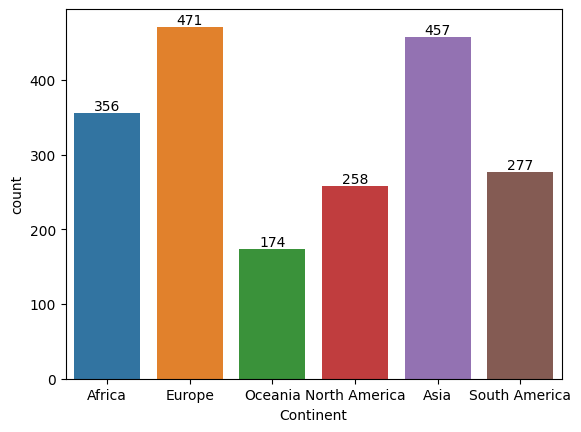

In [23]:
# plotting a bar chart for Continent and it's count
ax = sns.countplot(x = 'Continent',data = df)
for bars in ax.containers:
    ax.bar_label(bars)

*  This **Bar Char**t for Continent and it's count showing the total number of travel destinations in each Continent

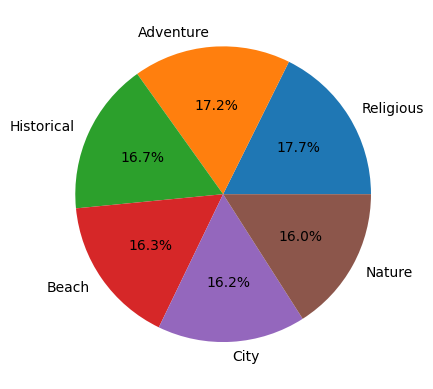

In [24]:
# plotting a pie chart for Destination Type and it's count
x = df['Destination_Type'].value_counts()
plt.pie(x.values,
        labels=x.index,
        autopct='%1.1f%%')
plt.show()

* This **Pie Chart** for Destination Type showing the total number of travel destinations types available.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Avg_Cost(USD/day)', ylabel='Count'>

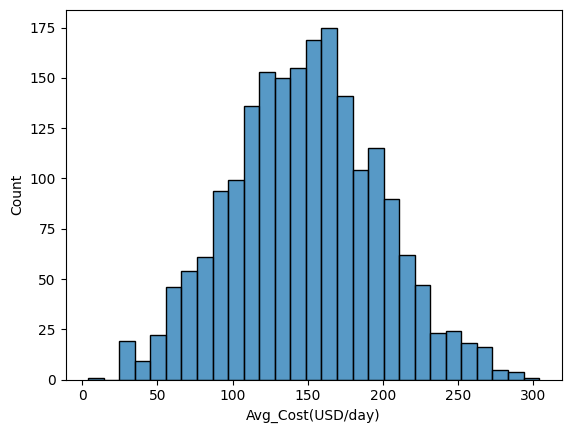

In [25]:
# plotting a Histogram for Avg Cost per day
sns.histplot(df['Avg_Cost(USD/day)'])

* This **Histogram** is designed to visualize the distribution of Average per Day travel costs in the given dataset.


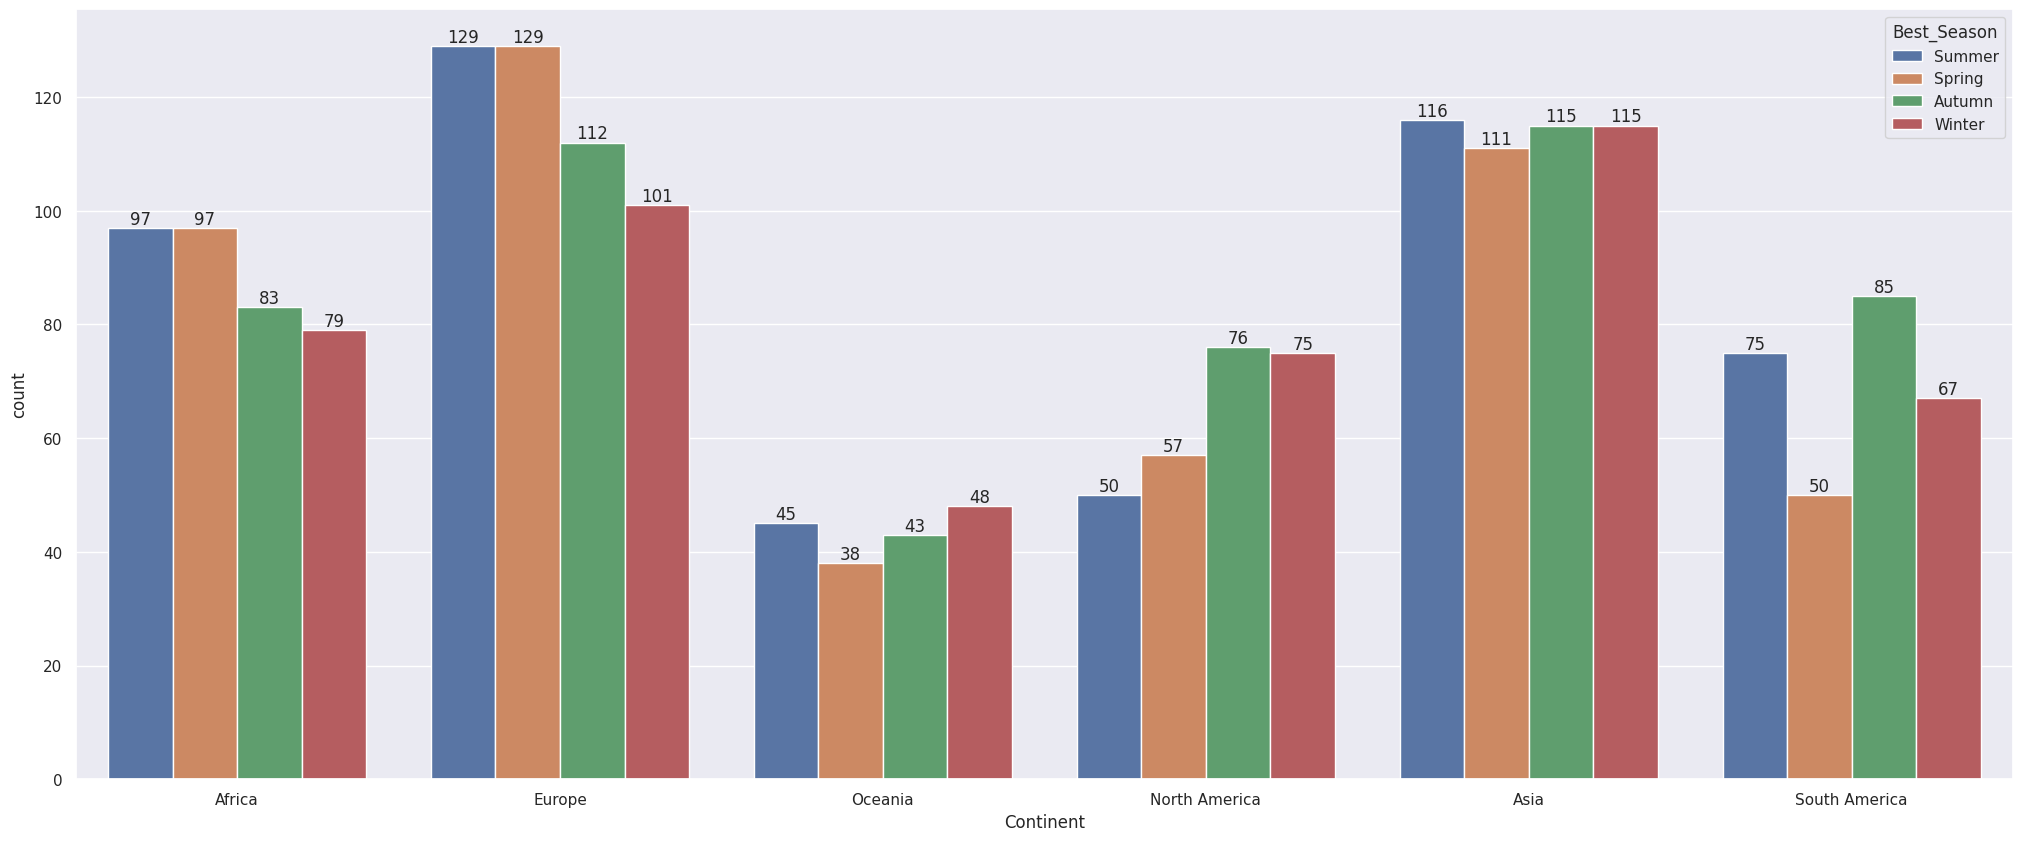

In [26]:
sns.set(rc={'figure.figsize':(25,10)})
ax = sns.countplot(data = df, x = 'Continent',hue = 'Best_Season')

for bars in ax.containers:
    ax.bar_label(bars)

# Bivariate Graphs

<Axes: xlabel='Country', ylabel='Annual_Visitors_M'>

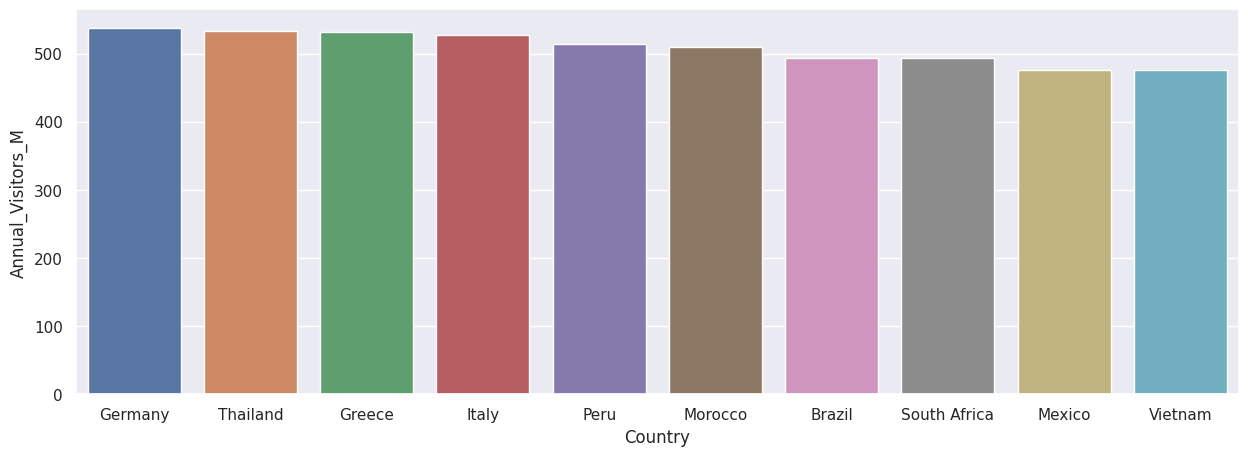

In [27]:
# total number of Annual Visitors in Millions from top 10 Country

sales_state = df.groupby(['Country'], as_index=False)['Annual_Visitors_M'].sum().sort_values(by='Annual_Visitors_M', ascending=False).head(10)

sns.set(rc={'figure.figsize':(15,5)})
sns.barplot(data = sales_state, x = 'Country',y= 'Annual_Visitors_M')

* This **Bar Chart** is designed to visualize the data with total numbers of Annual Visitors in Millions vs the top 10 Countries.

<Axes: xlabel='Country', ylabel='Avg_Cost(USD/day)'>

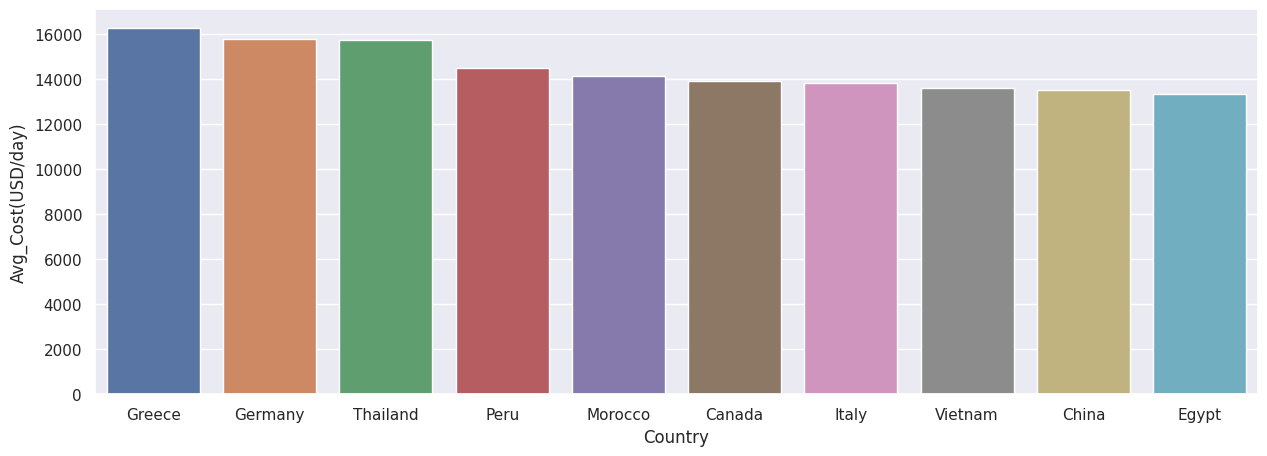

In [28]:
# total amount/sales from top 10 states

sales_state = df.groupby(['Country'], as_index=False)['Avg_Cost(USD/day)'].sum().sort_values(by='Avg_Cost(USD/day)', ascending=False).head(10)

sns.set(rc={'figure.figsize':(15,5)})
sns.barplot(data = sales_state, x = 'Country',y= 'Avg_Cost(USD/day)')

* This **Bar Chart** is designed to visualize the data with Average Cost per day in USD Dollar vs the top 10 Countries.
* This chart show which country is **more expensive to travel**.

# Trivariate Graphs

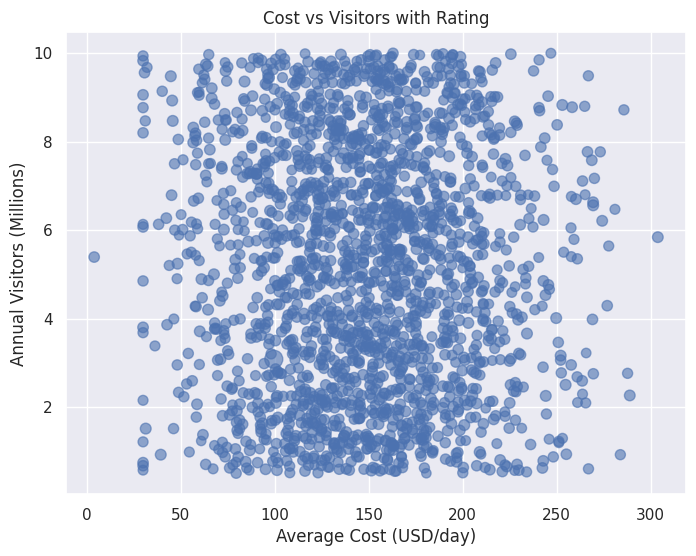

In [29]:
plt.figure(figsize=(8,6))
plt.scatter(
    df['Avg_Cost(USD/day)'],
    df['Annual_Visitors_M'],
    s=df['Avg_Rating']*12,  # bubble size
    alpha=0.6
)
plt.xlabel('Average Cost (USD/day)')
plt.ylabel('Annual Visitors (Millions)')
plt.title('Cost vs Visitors with Rating')
plt.show()


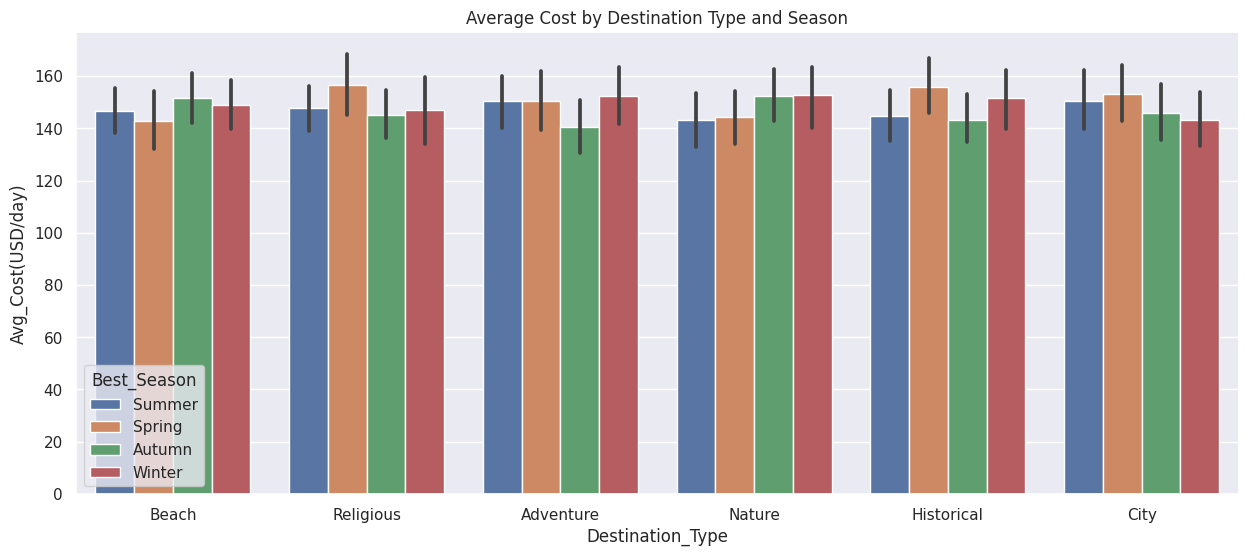

In [30]:
plt.figure(figsize=(15,6))
sns.barplot(
    data=df,
    x='Destination_Type',
    y='Avg_Cost(USD/day)',
    hue='Best_Season'
)
plt.title('Average Cost by Destination Type and Season')
plt.show()


# Create Correlation Graph

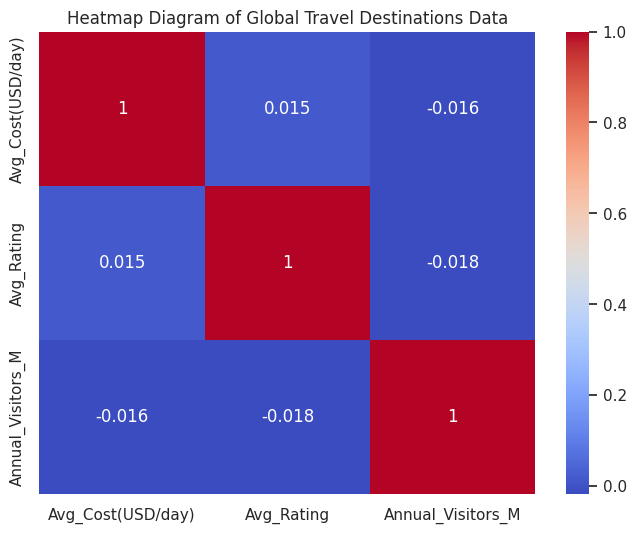

In [31]:
# Select only numerical columns
num_df = df.select_dtypes(include=['int64', 'float64'])

# Create correlation matrix
corr = num_df.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Heatmap Diagram of Global Travel Destinations Data')
plt.show()


* This **Heatmap** is designed to visualize Relationship between numerical columns like Avg Cost, Avg Rating, and Annual Visitors


# Outliers

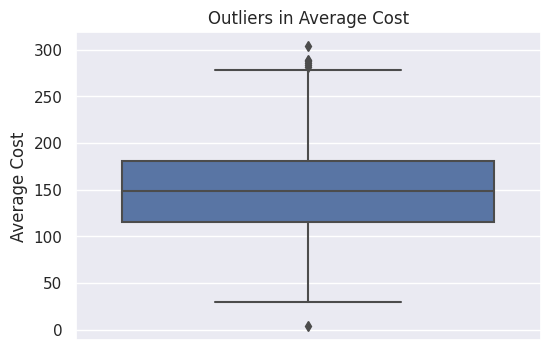

In [32]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['Avg_Cost(USD/day)'])
plt.title('Outliers in Average Cost')
plt.ylabel('Average Cost')
plt.show()

# Statistical Methods

**Mean**

In [33]:
cost_mean = np.mean(df["Avg_Cost(USD/day)"])
cost_mean

148.27218263923731

**Median**

In [34]:
cost_median = np.median(df["Avg_Cost(USD/day)"])
cost_median

148.66

**Mode**

In [35]:
Continent_mode = multimode(df["Continent"])
Continent_mode

['Europe']

In [36]:
Country_mode = multimode(df["Country"])
Country_mode

['Germany']

# Conclusion

**This Data Visualization Project demonstrates**
* the **Continent Europe** has higher numbers of global tourist sports to visit in the season **Summer and Spring**.
* Global tourist mostly prefer **Religious** destinations.
* Most of the tourists spend average **100-200 USD dollars** per day.
* Country **Germany** has highest ration of Global tourists 
* Country **Greece** is more expensive to travel. 

# Reference Link
* https://www.kaggle.com/datasets/cosmox23/popular-tourist-destinations-and-their-features